In [47]:
from utils import globals

import pandas as pd
import os
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import iplot
from scipy.fftpack import fft
from importlib import reload

In [17]:
orig = globals.load_training()
train = orig.dropna().copy() #757 righe in meno

# Punti in cui avvengono le manutenzioni
wws = globals.get_shift('Cumulative_WWs', train)
hpc = globals.get_shift('Cumulative_HPC_SVs', train)
hpt = globals.get_shift('Cumulative_HPT_SVs', train)

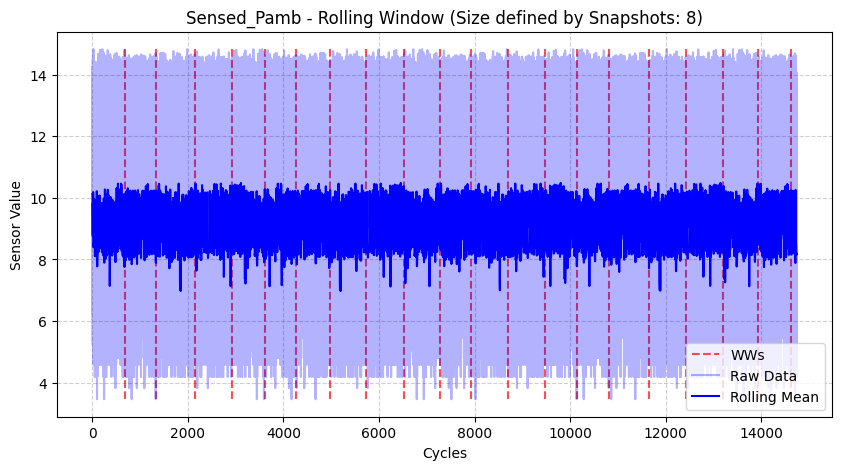

In [ ]:

reload(globals)
ESN=101
SENSOR = globals.SENSORS.Sensed_Pamb.value
roll = globals.filter(train, "ESN", ESN, [SENSOR, 'Snapshot'])
wsize = 8
rolling_mean = roll[SENSOR].rolling(window=wsize).mean()

# Plotting
plt.figure(figsize=(10, 5))
plt.vlines(wws.loc[wws['ESN'] == ESN].index, ymin=roll[SENSOR].min(), ymax=roll[SENSOR].max(), colors='red', linestyles='dashed', label='WWs', alpha=0.7)
plt.plot(train.loc[train['ESN'] == int(ESN), [SENSOR]], label='Raw Data', color='blue', alpha=0.3)
plt.plot(rolling_mean, label='Rolling Mean', color='blue')
plt.title(f'{SENSOR} - Rolling Window (Size defined by Snapshots: {wsize})')
plt.xlabel('Cycles')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(f"{globals.PLOT_PATH}/ROLLING-{SENSOR}-{wsize}-ESN{ESN}")
plt.show()


In [59]:
reload(globals)

ESN=104
points = hpt
plabel = "HPT"
method = "ROLLINGW"

path = f"{globals.PLOT_PATH}/{method}/{ESN}/"
os.makedirs(os.path.dirname(path), exist_ok=True)
for sensor in globals.SENSORS.iter():
    SENSOR = sensor
    roll = globals.filter(train, "ESN", ESN, [SENSOR, 'Snapshot'])
    wsize = 8
    rolling_mean = roll[SENSOR].rolling(window=wsize).mean()

# Plotting
    plt.figure(figsize=(10, 5))
    plt.vlines(points.loc[points['ESN'] == ESN].index, ymin=roll[SENSOR].min(), ymax=roll[SENSOR].max(), colors='red', linestyles='dashed', label=plabel, alpha=0.7)
    plt.plot(train.loc[train['ESN'] == int(ESN), [SENSOR]], label='Raw Data', color='blue', alpha=0.3)
    plt.plot(rolling_mean, label='Rolling Mean', color='blue')
    plt.title(f'{SENSOR} - Rolling Window (Size defined by Snapshots: {wsize})')
    plt.xlabel('Cycles')
    plt.ylabel('Sensor Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.savefig(f"{path}/{SENSOR}-{plabel}-{wsize}")



Error in callback <function flush_figures at 0x7f91426a0e50> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

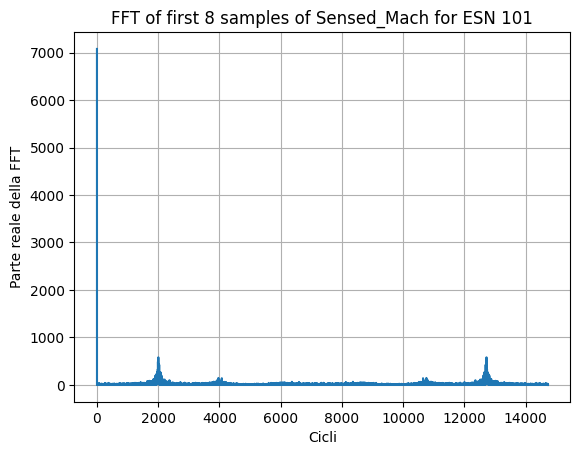

In [ ]:
reload(globals)

method = "FFT"

for sensor in globals.SENSORS.iter():
    for esn in globals.ESN:
        path = f"{globals.PLOT_PATH}/{method}/{esn}/"
        os.makedirs(os.path.dirname(path), exist_ok=True)
        plt.figure(figsize=(10, 5))
# Plotting
        l = len(train[sensor])
        np.linspace(0.0, )
        plt.title(f'{sensor} - FFT)')
        plt.xlabel('Frequency')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        
        plt.savefig(f"{path}/{SENSOR}-{plabel}-{wsize}")





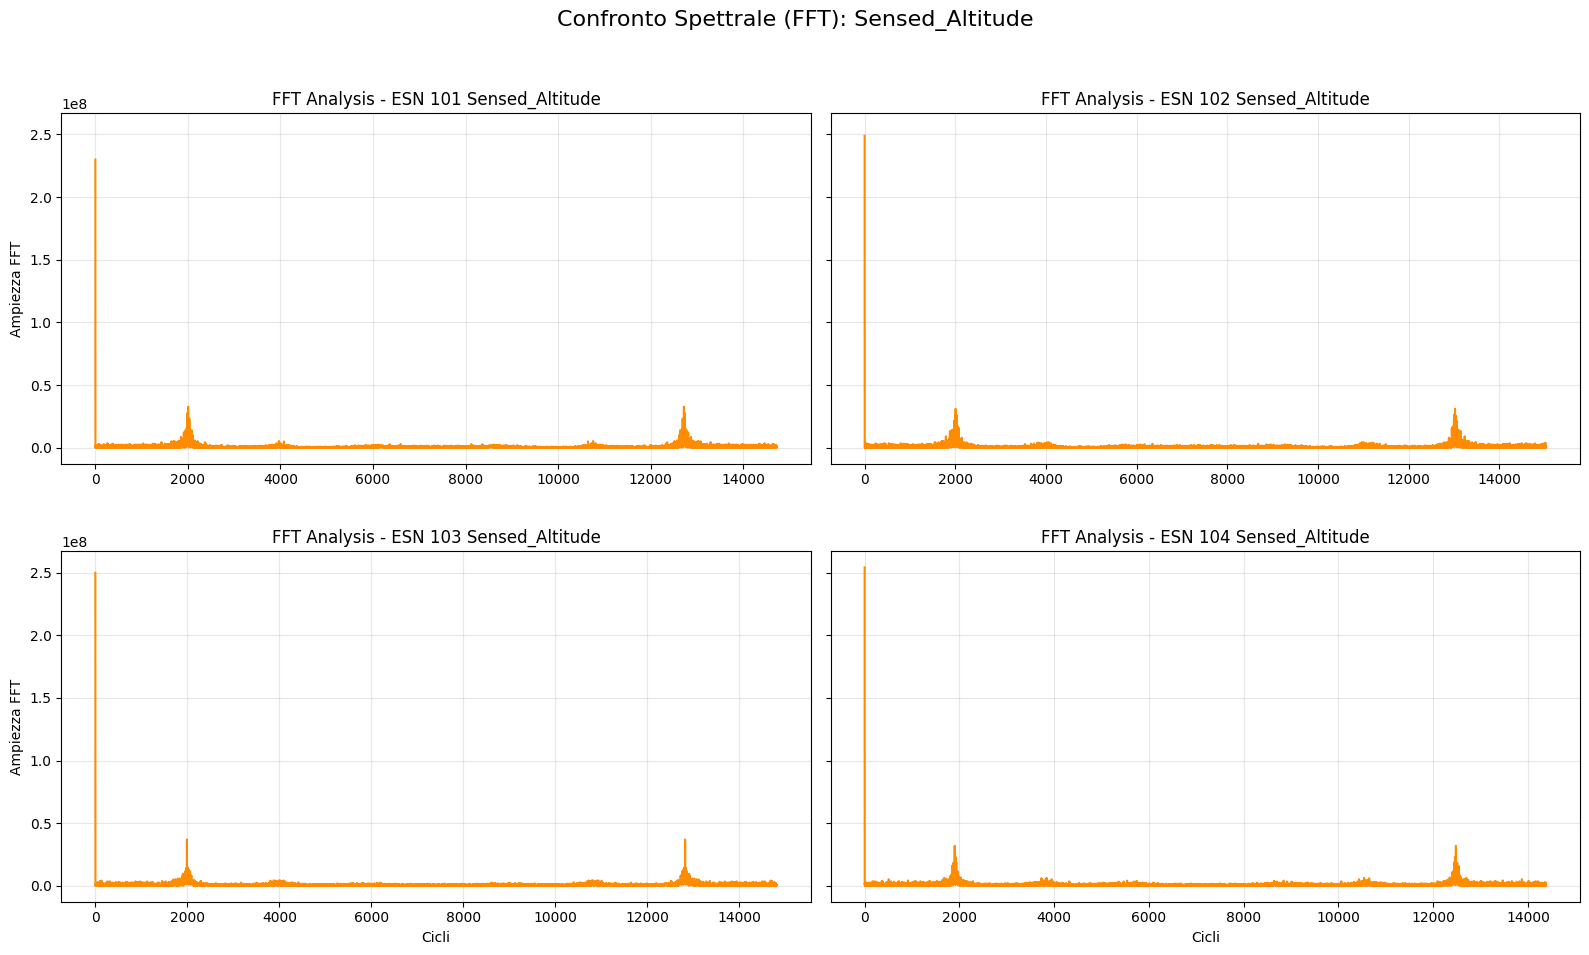

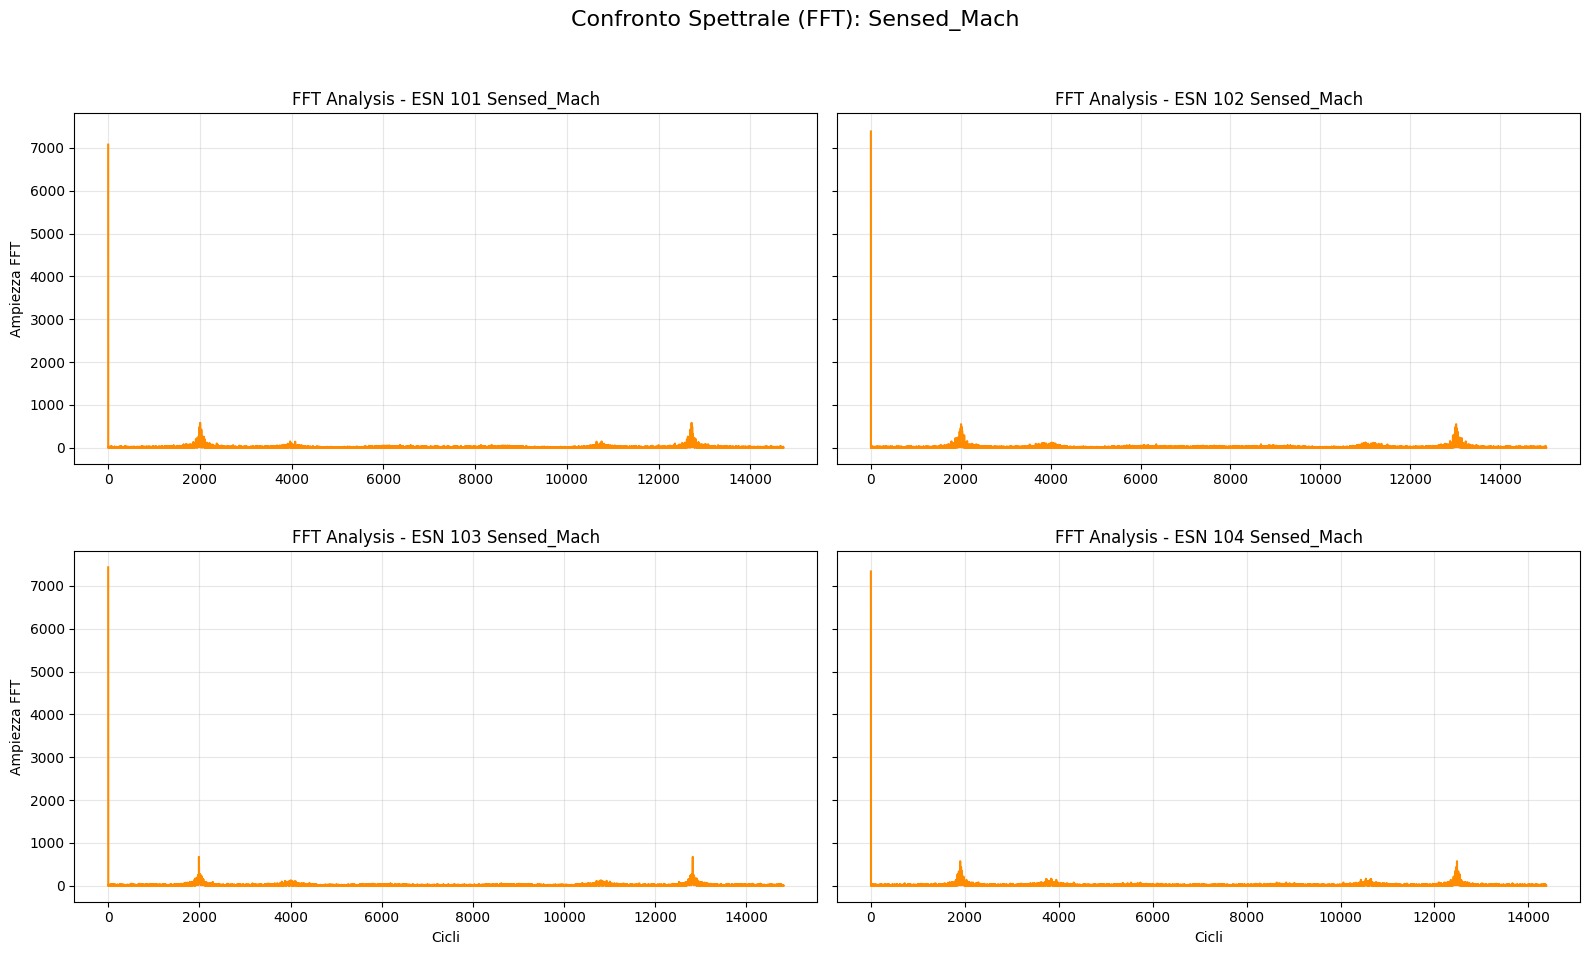

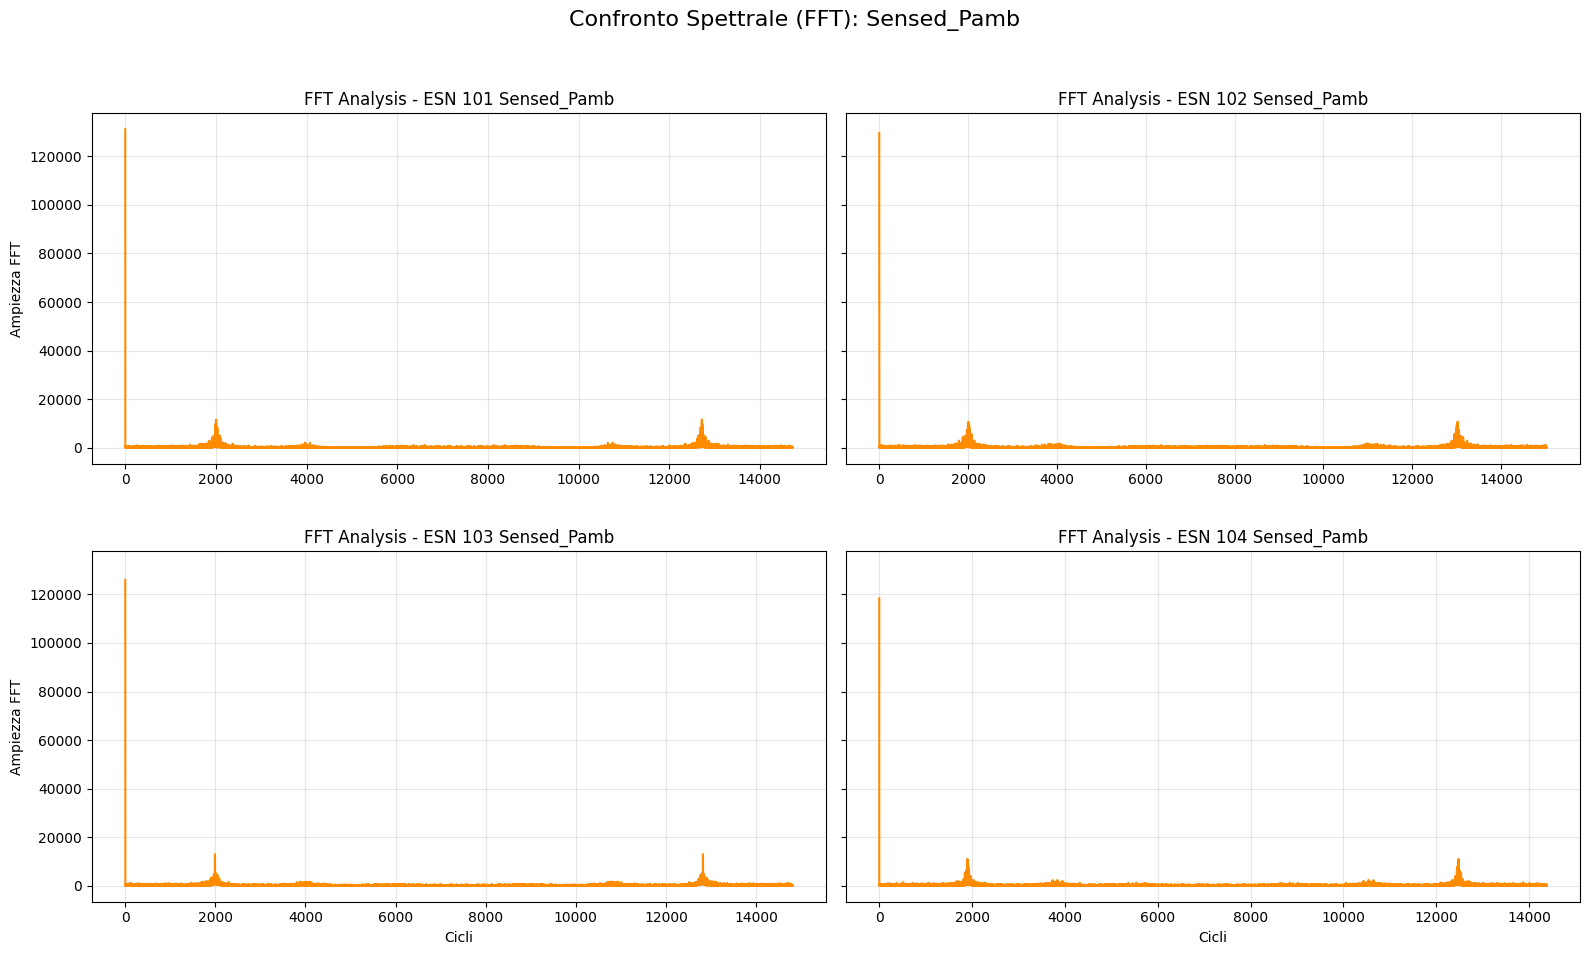

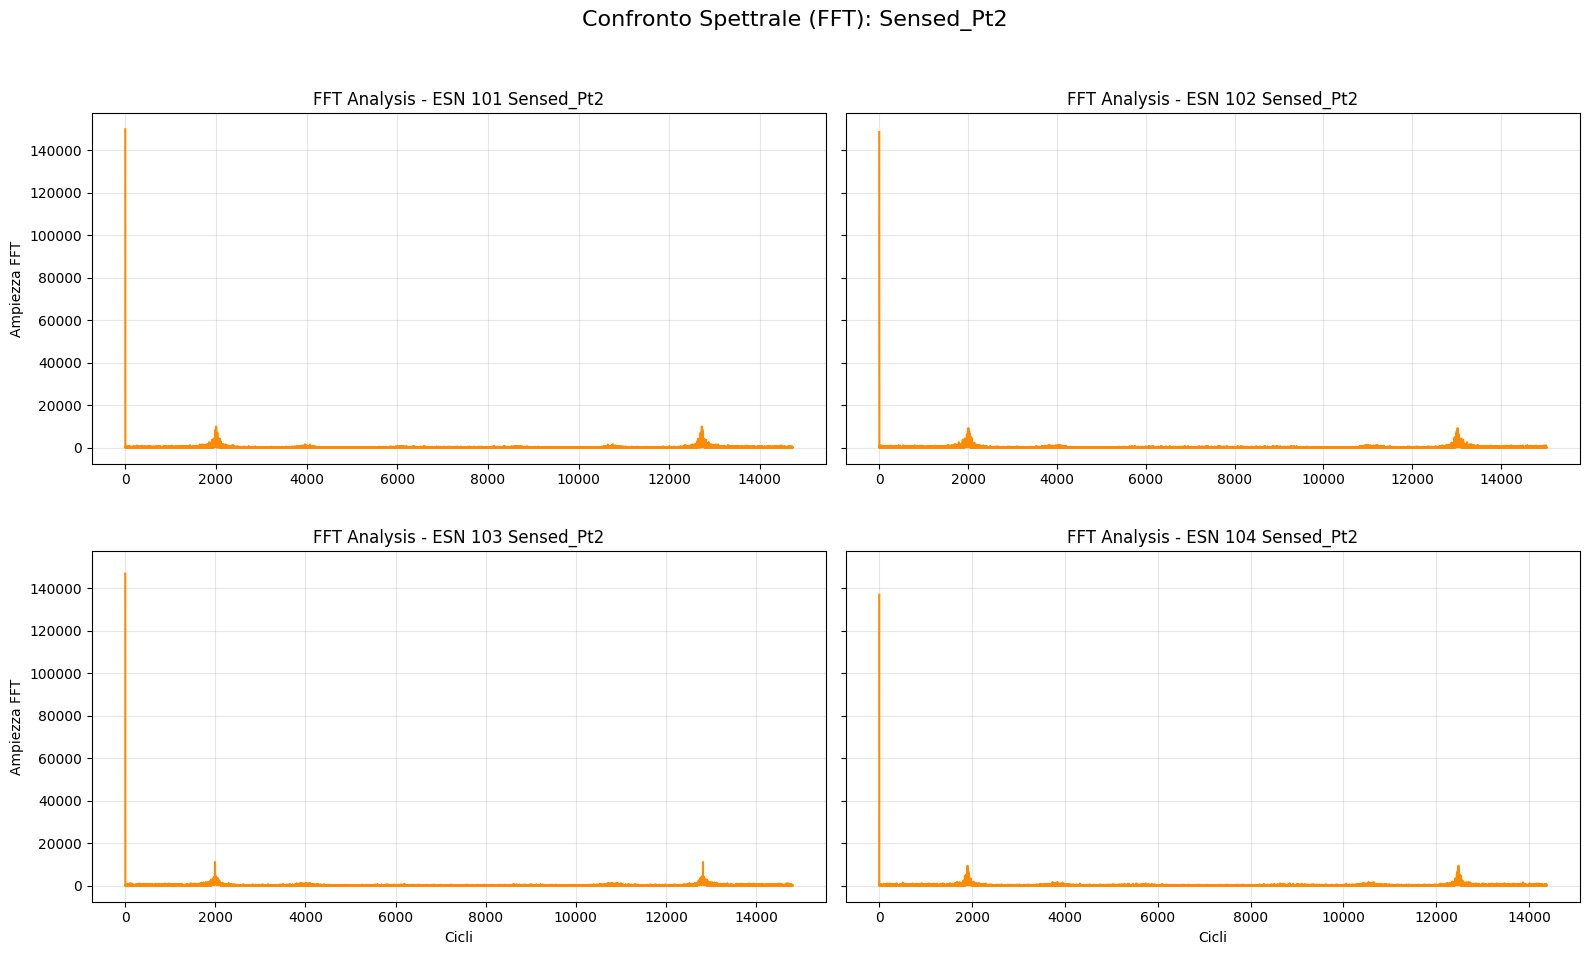

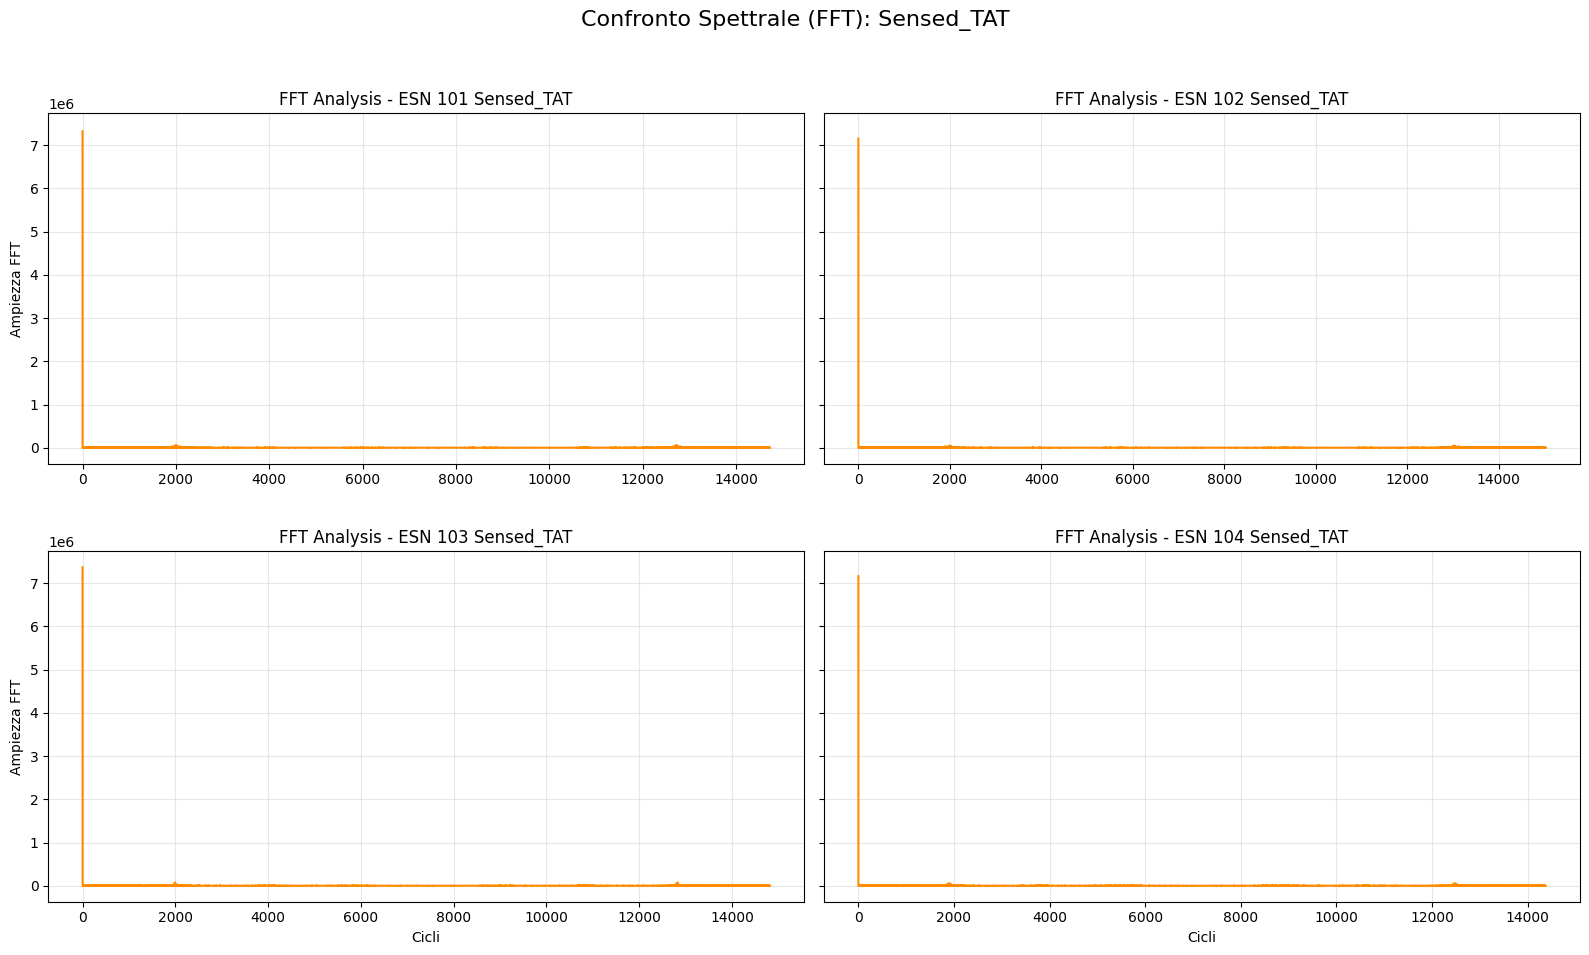

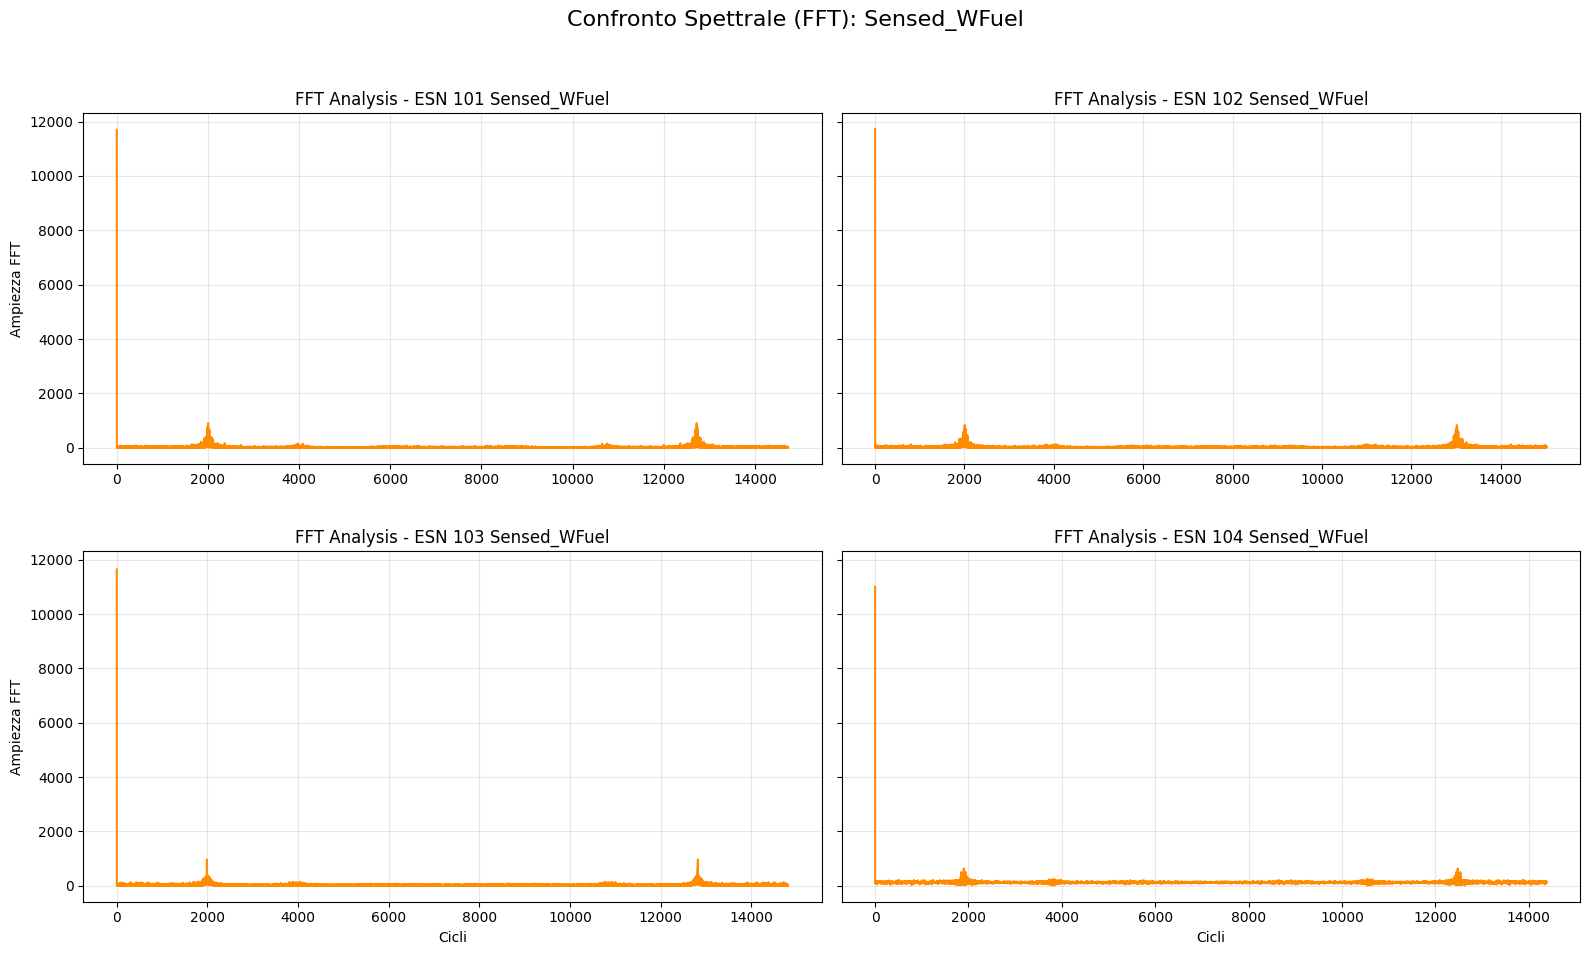

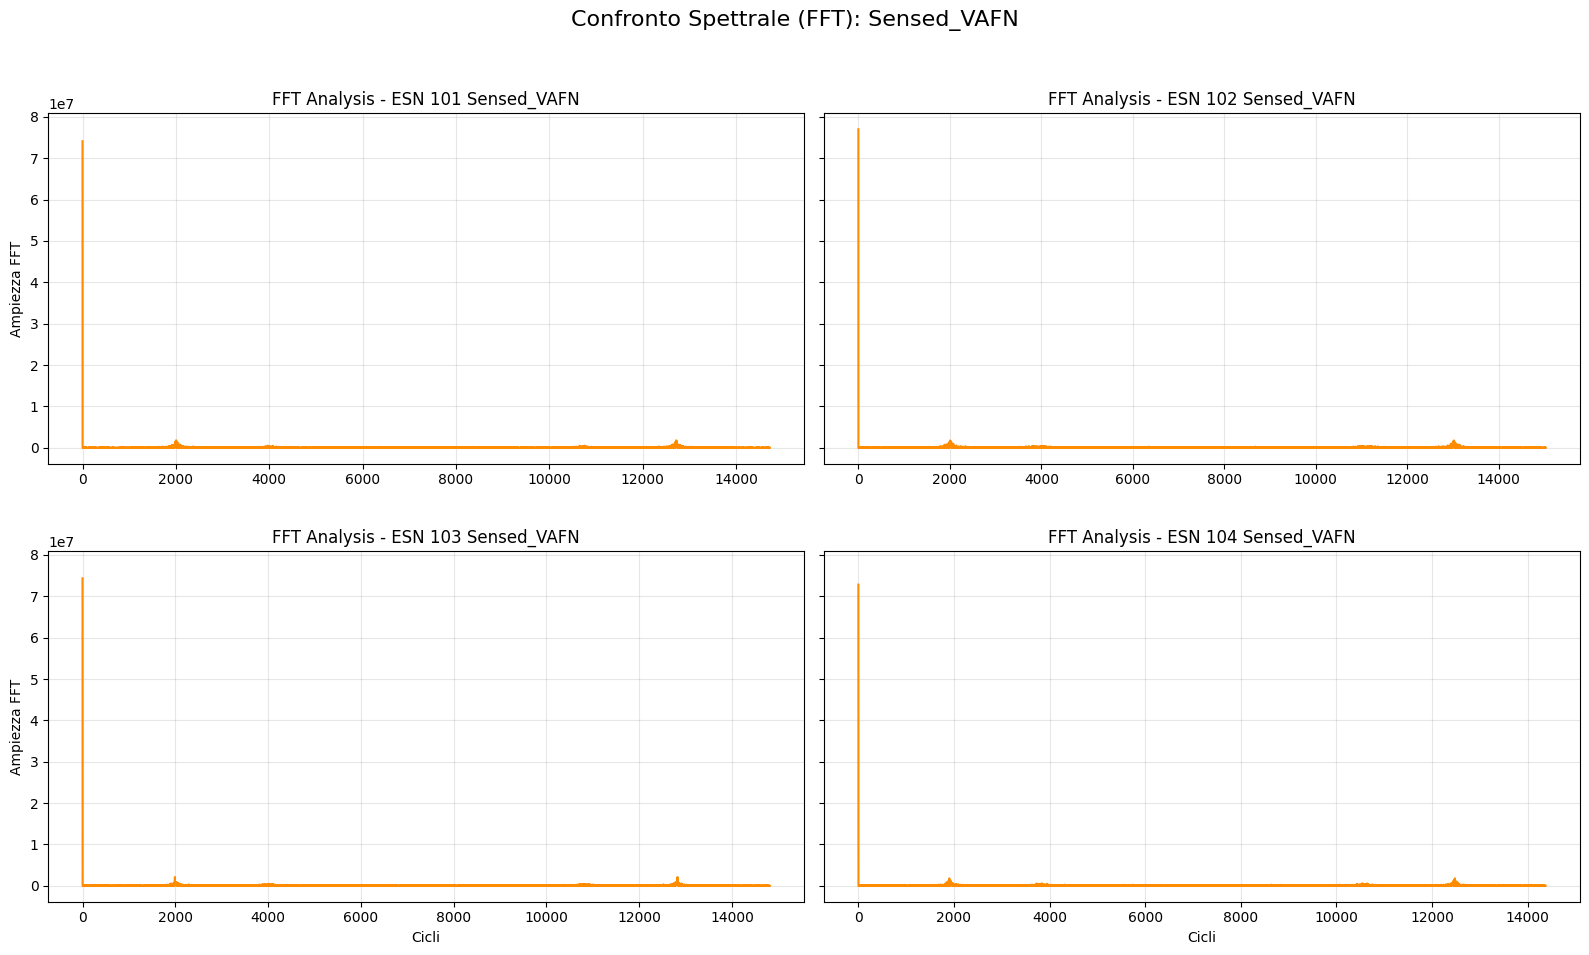

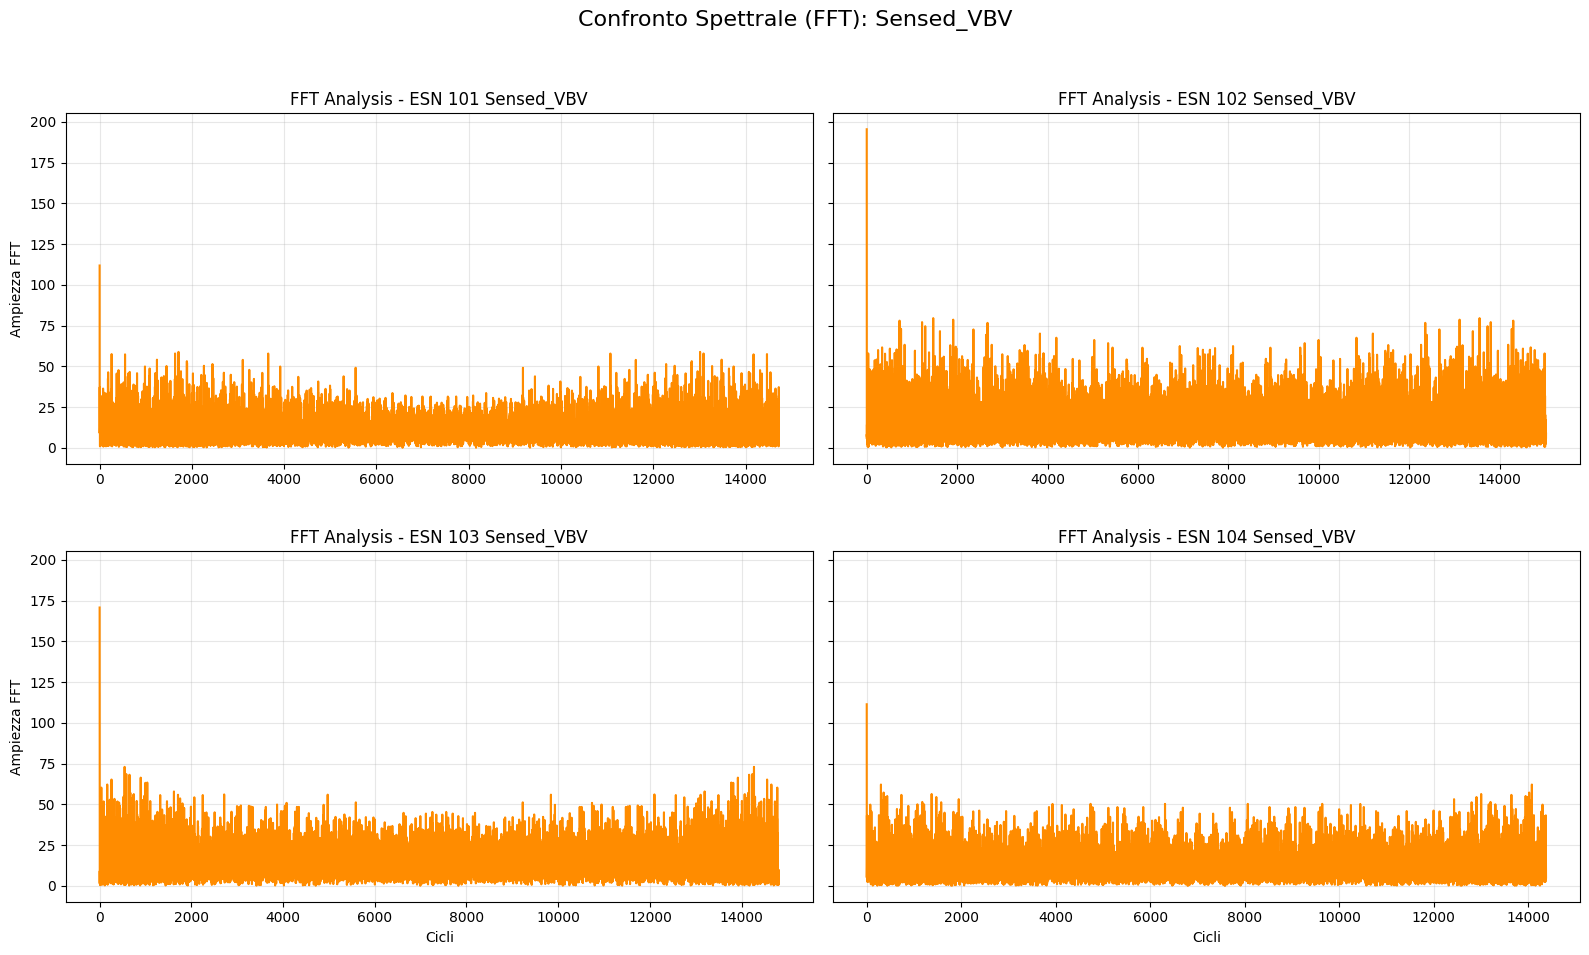

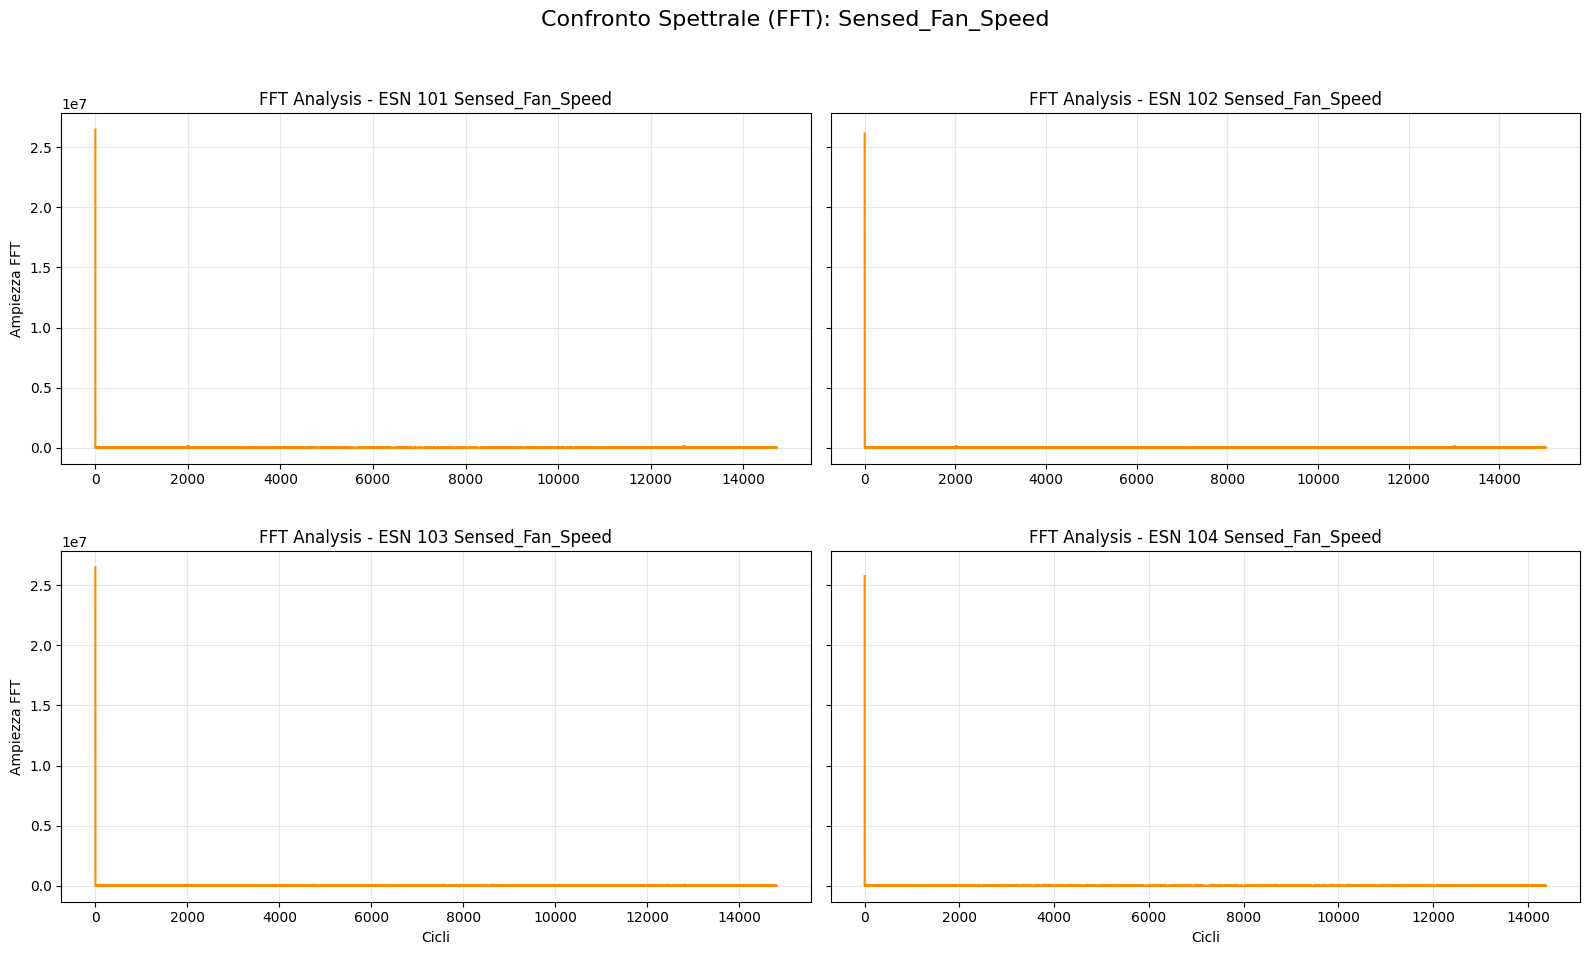

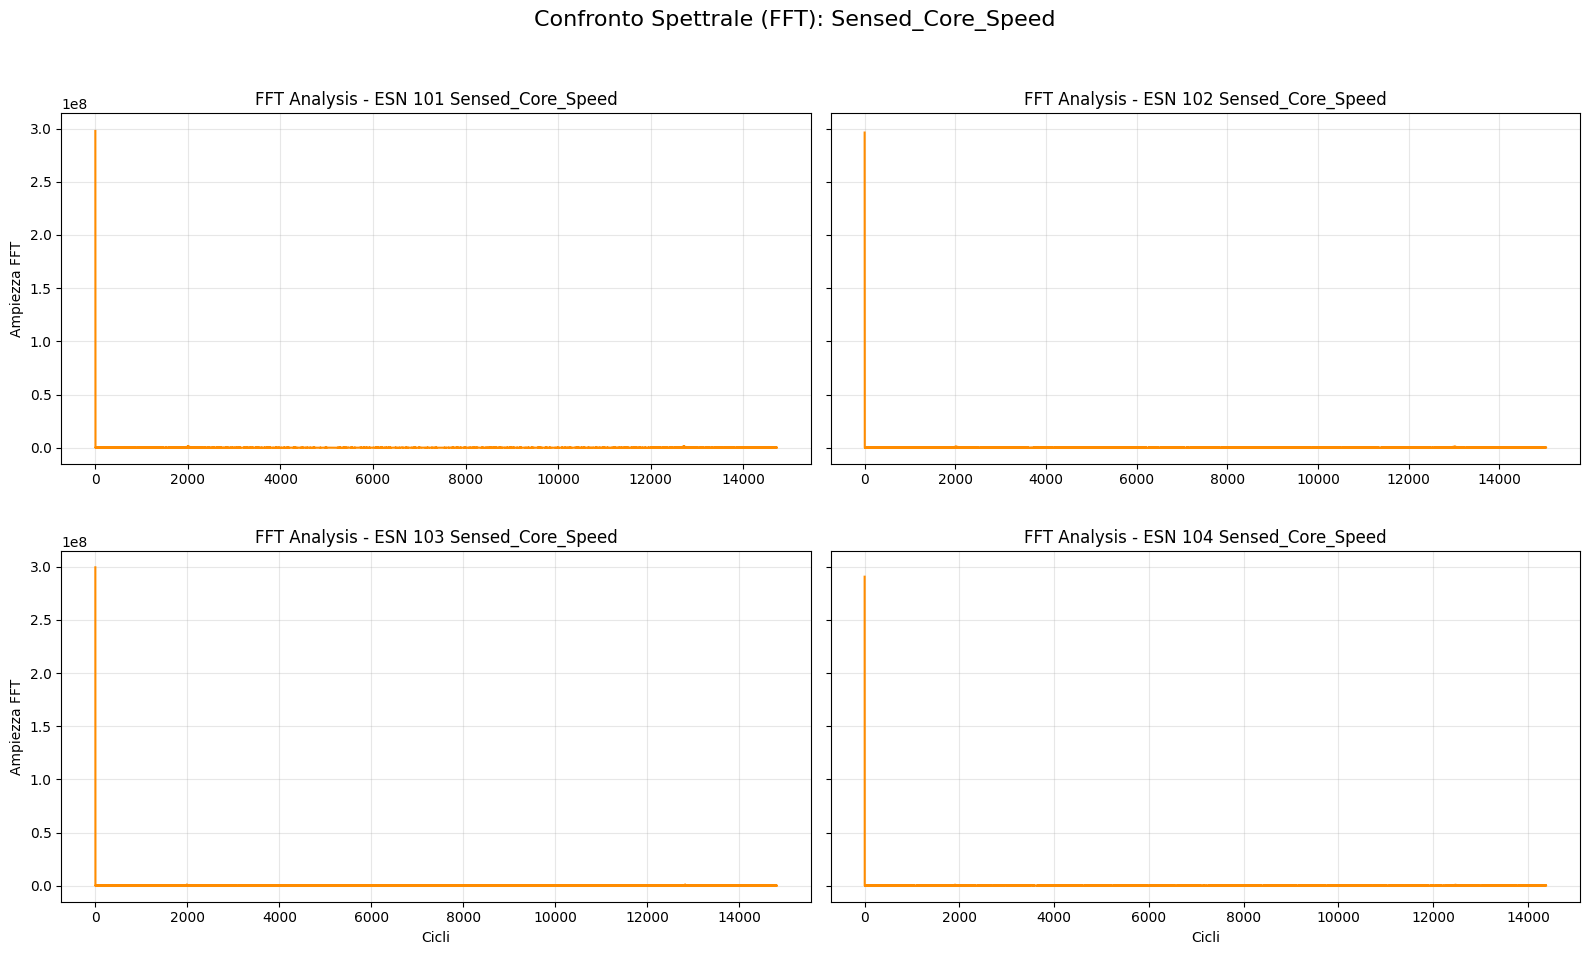

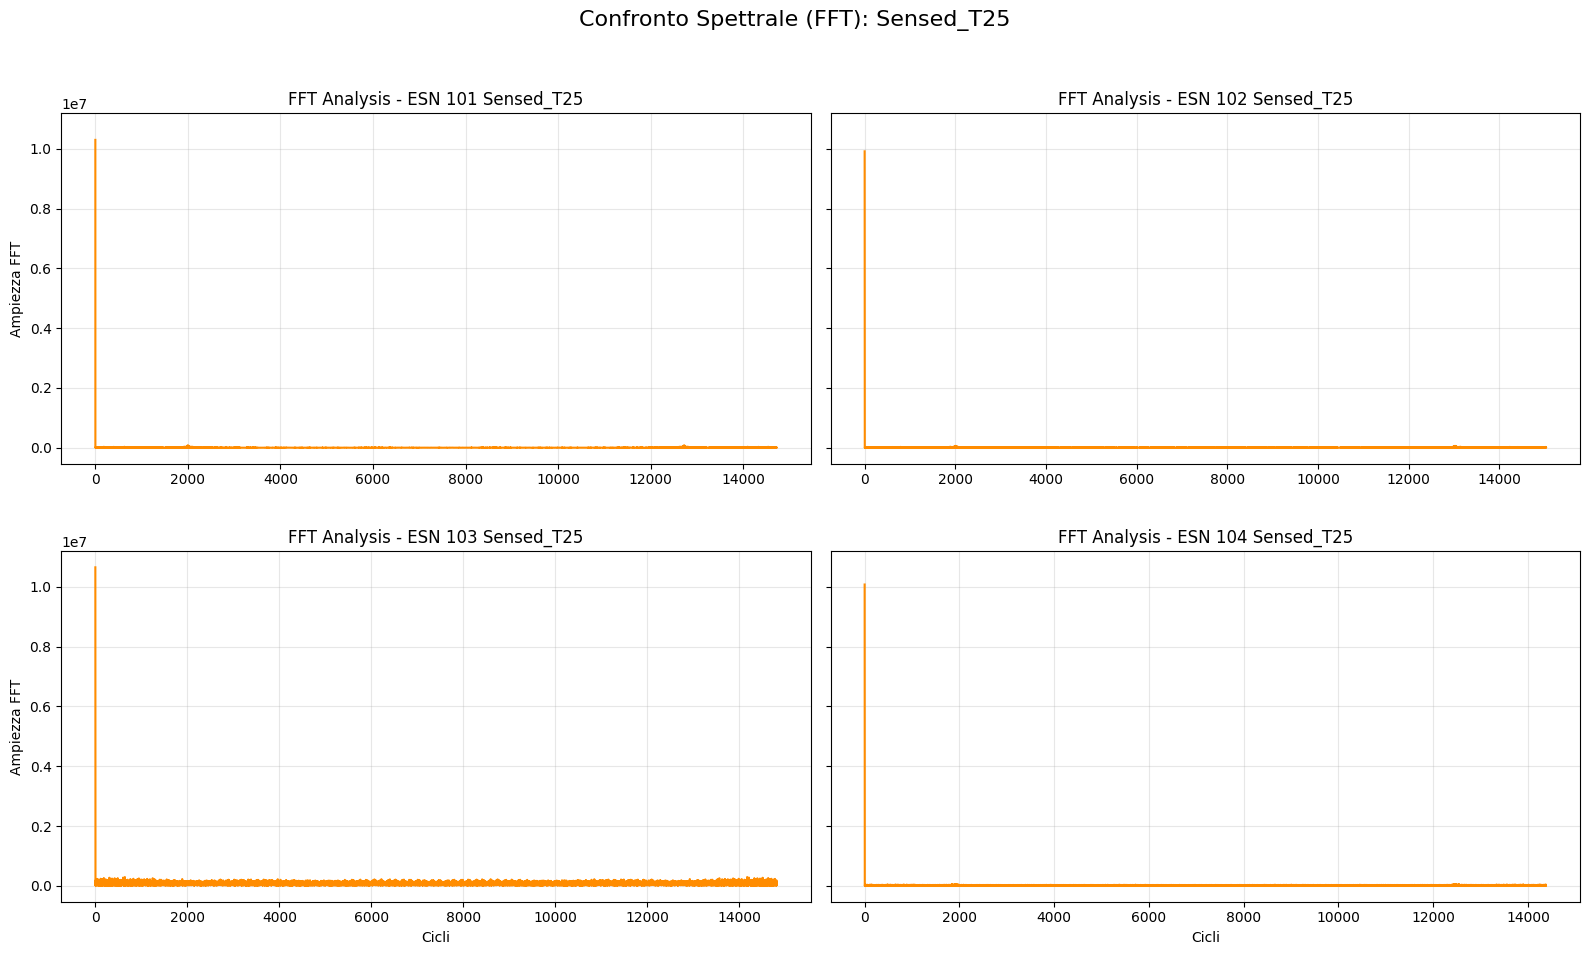

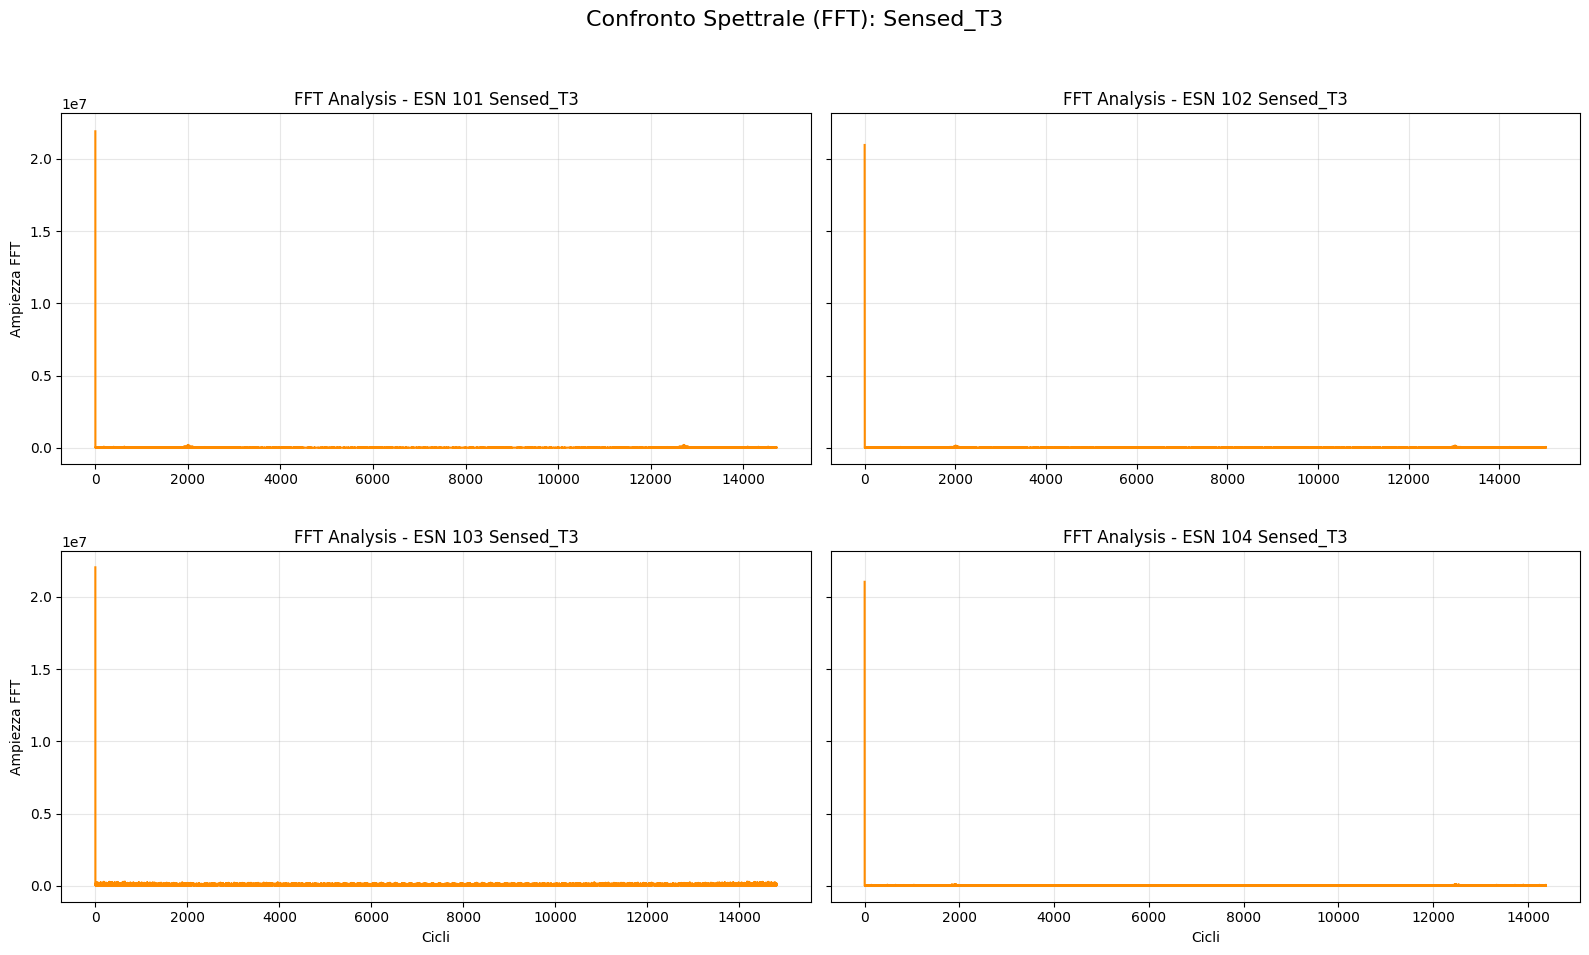

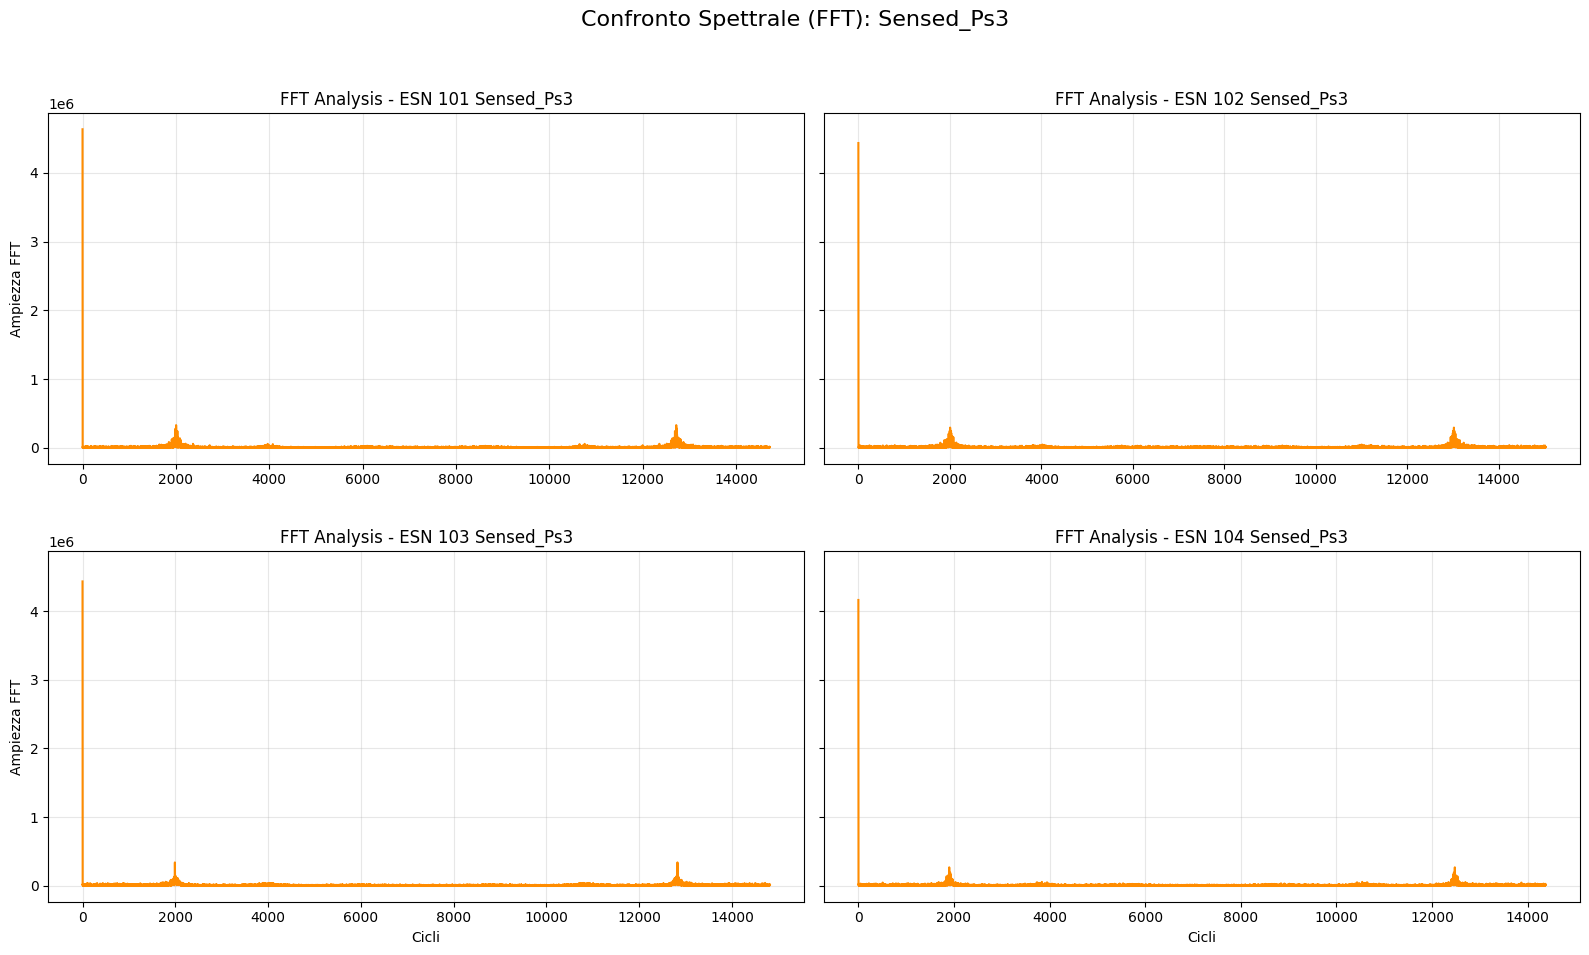

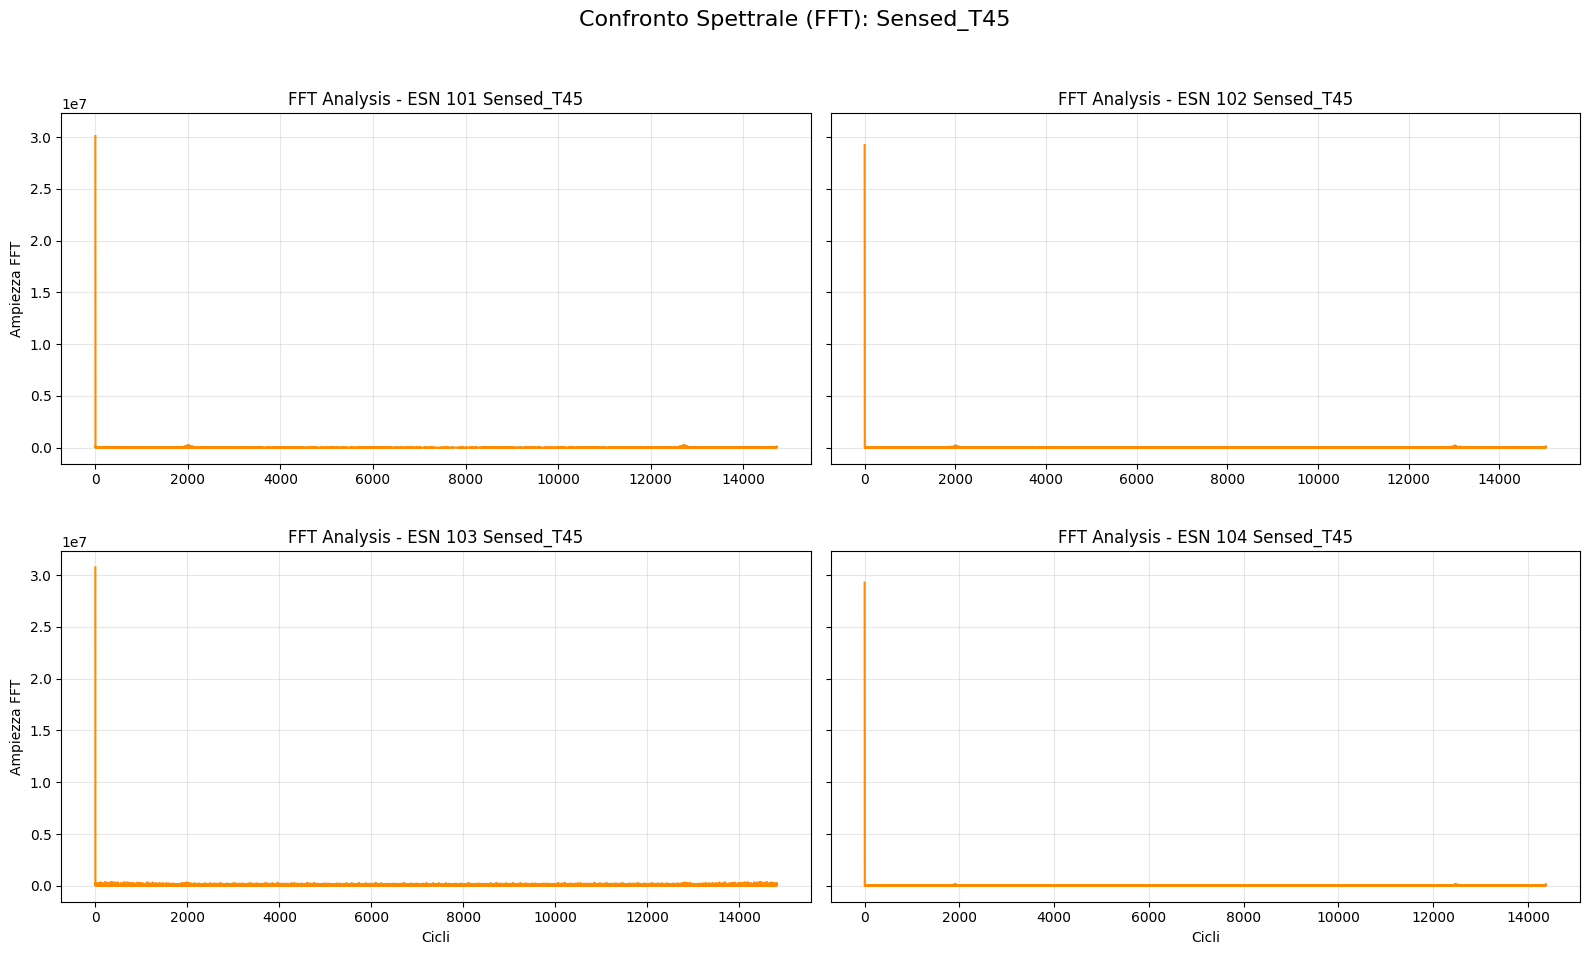

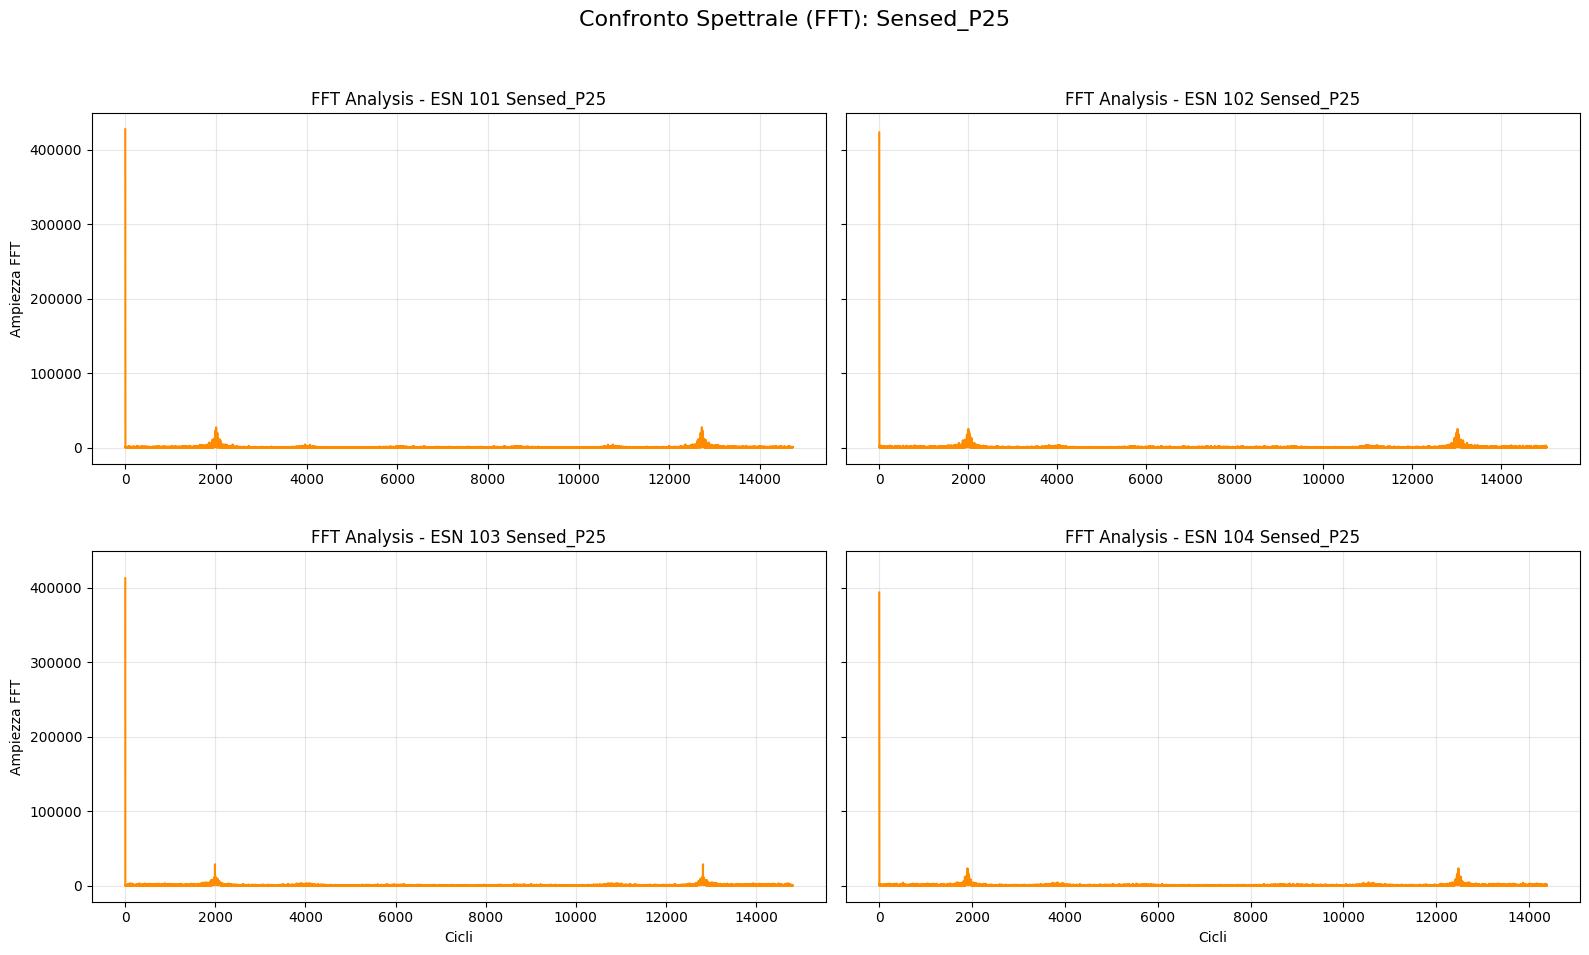

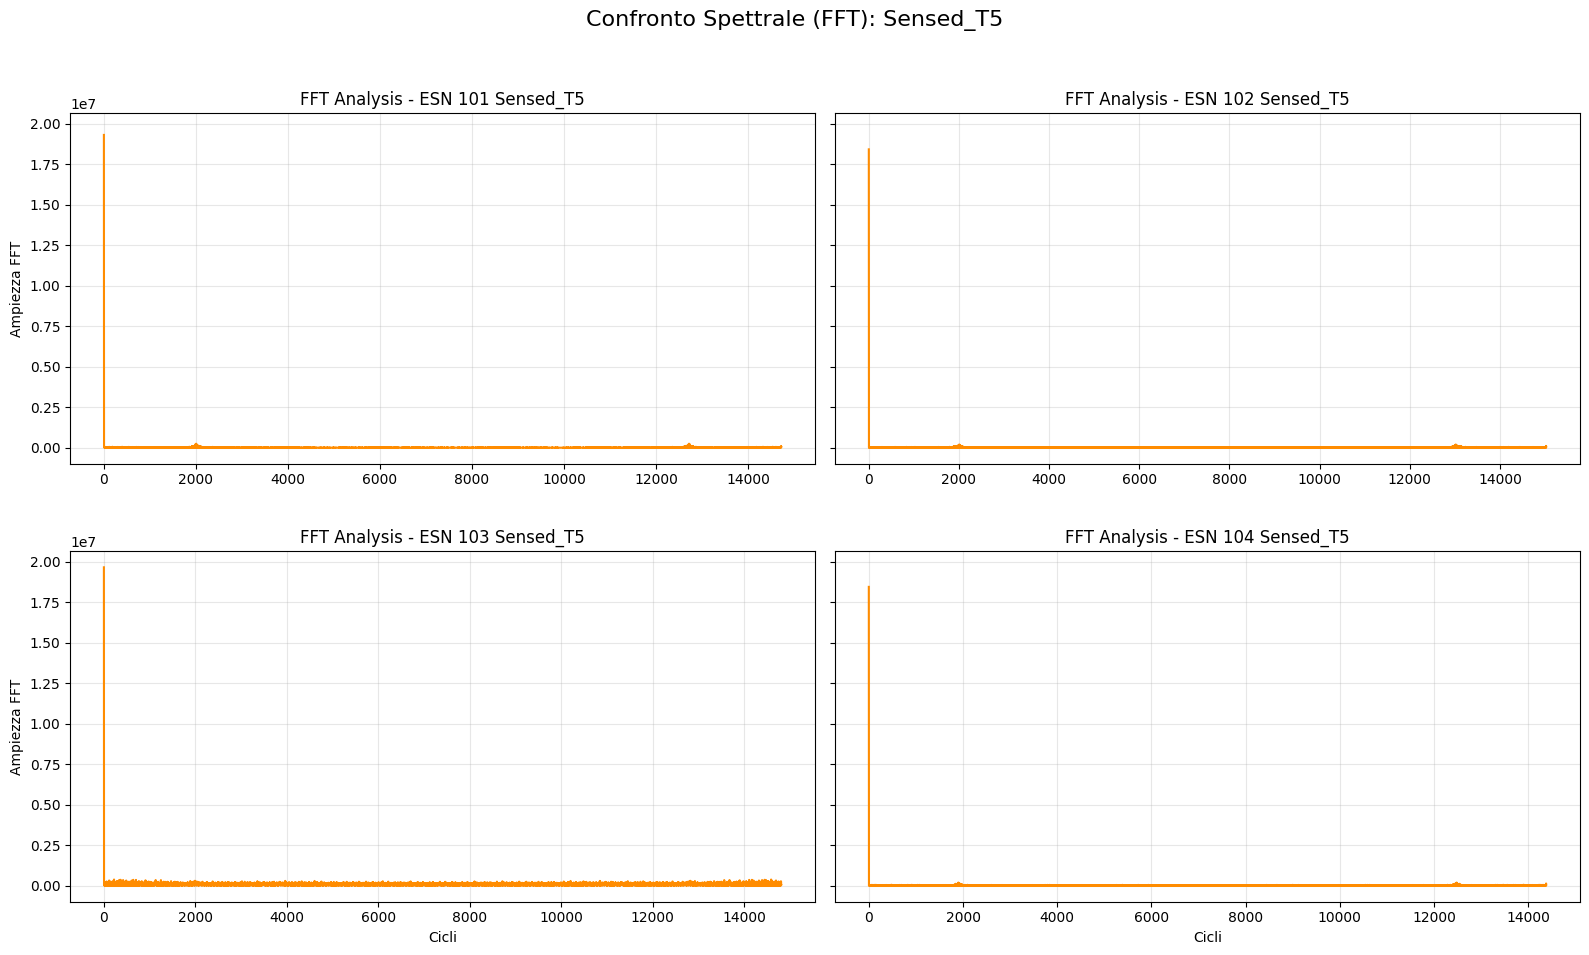

In [64]:
for sensor in globals.SENSORS.iter():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()
    for i, esn_id in enumerate(train['ESN'].unique()):
        ax = axes[i]

        roll = train.loc[train['ESN'] == int(esn_id), [sensor]].copy()
        x = roll[sensor].values

        yf = fft(x)
        t = np.linspace(0, len(x), len(x), endpoint=False)

        ax.plot(t, np.abs(yf), color='darkorange')

        ax.set_title(f'FFT Analysis - ESN {esn_id} {sensor}')
        ax.grid(True, alpha=0.3)
        if i >= 2: ax.set_xlabel('Cicli')
        if i % 2 == 0: ax.set_ylabel('Ampiezza FFT')

    fig.suptitle(f'Confronto Spettrale (FFT): {sensor}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=3.0)
    plt.show()